In [12]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Early-Sepsis-Detection


In [13]:
!pip install xgboost lightgbm catboost -q
!pip install optuna -q
!pip install tensorflow -q

In [14]:
!pip install shap -q

# 19 — Error Analysis
### Early Sepsis Detection — Phase 21

Systematically examines False Positives and False Negatives from
**LightGBM (tuned) + isotonic calibration + threshold=0.1** (our locked
final model from Phase 19), using the validation set.

**Hypothesis carried forward from Phase 20's false-negative example:**
patients whose sepsis develops gradually (longer time to onset, more
"normal-looking" early vitals) may be systematically harder to catch than
patients with a dramatic, rapid-onset presentation. This is tested here
against the actual data, not assumed.

Patterns are reported only where they are actually observed in the data —
no explanation is invented beyond what the evidence supports.


In [15]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from src import config
from src import evaluate as ev

npz = np.load(config.PROCESSED_DIR / "model_ready_arrays.npz")
X_val, y_val = npz["X_val"], npz["y_val"]

split_lookup = pd.read_parquet(config.PROCESSED_DIR / "patient_split_assignment.parquet")
val_ids = split_lookup.loc[split_lookup["split"] == "val", config.PATIENT_ID_COL].to_numpy()

patient_df = pd.read_parquet(config.PROCESSED_PATIENT_LEVEL_PARQUET)
# CRITICAL: X_val's row order matches patient_df's ORIGINAL row order
# filtered to val patients (see src/preprocessing.py transform_split, which
# does `sub = patient_df[patient_df[PATIENT_ID_COL].isin(patient_ids)]` —
# this does NOT reorder to match `patient_ids`'s own sequence). Re-indexing
# to val_ids' (shuffled) order here, as an earlier version of this notebook
# did, silently misaligns every prediction with the wrong patient. We
# replicate the EXACT SAME filter (not a reorder) to guarantee X_val and
# patient_df_val rows correspond 1:1, position for position.
patient_df_val = patient_df[patient_df[config.PATIENT_ID_COL].isin(val_ids)].reset_index(drop=True)

assert len(patient_df_val) == X_val.shape[0], (
    f"Row count mismatch: patient_df_val has {len(patient_df_val)} rows but "
    f"X_val has {X_val.shape[0]} — the alignment assumption above is violated."
)

model = joblib.load(config.MODELS_DIR / "lightgbm_tuned.pkl")
raw_val_prob = model.predict_proba(X_val)[:, 1]

FINAL_THRESHOLD = 0.1  # from Phase 19's isotonic-calibrated re-derivation

# Reuse the calibrator if available for the actual deployed probability
calibrated_path = config.MODELS_DIR / "lightgbm_tuned_calibrated.pkl"
if calibrated_path.exists():
    calibrator = joblib.load(calibrated_path)
    val_prob = calibrator.predict_proba(X_val)[:, 1]
    print("Using CALIBRATED probabilities for error grouping.")
else:
    val_prob = raw_val_prob
    print("Calibrator not found — using uncalibrated probabilities.")

val_pred = (val_prob >= FINAL_THRESHOLD).astype(int)
patient_df_val["pred_prob"] = val_prob
patient_df_val["pred_label"] = val_pred


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Using CALIBRATED probabilities for error grouping.


### Alignment sanity check

This check exists because an earlier version of this notebook had a
silent ordering bug (re-indexing patient metadata to a different order
than the model's input array) that scrambled every TP/FP/FN/TN label.
This assertion makes that class of bug impossible to miss going forward.


In [16]:
# MANDATORY alignment check: patient_df_val's "label" column (from the
# feature-engineered parquet) must exactly match y_val (from the npz array
# used to generate predictions). If these ever disagree, predictions are
# misaligned with patients and NOTHING downstream in this notebook can be
# trusted — this must show a perfect match before proceeding.
labels_match = (patient_df_val["label"].to_numpy() == y_val).all()
print(f"patient_df_val['label'] matches y_val for all {len(y_val)} patients: {labels_match}")
assert labels_match, "ALIGNMENT BUG: patient_df_val and X_val/y_val are in different orders!"


patient_df_val['label'] matches y_val for all 5905 patients: True


## 1. Define error groups

In [17]:
def outcome(row):
    if row["label"] == 1 and row["pred_label"] == 1:
        return "TP"
    if row["label"] == 0 and row["pred_label"] == 0:
        return "TN"
    if row["label"] == 0 and row["pred_label"] == 1:
        return "FP"
    return "FN"

patient_df_val["outcome"] = patient_df_val.apply(outcome, axis=1)
display(patient_df_val["outcome"].value_counts())


,count
outcome,
TN,4483
FP,1053
TP,211
FN,158


## 2. False Negatives — does onset timing/history length matter?

**Hypothesis:** patients with a very short usable pre-onset window (sepsis
detected/onset very early in their stay) may be harder to catch, since the
model has less history to work with — OR conversely, patients with LONGER
onset times (more gradual) may look "too normal" early on. Both directions
are checked, not assumed.


In [18]:
fn_vs_tp = patient_df_val[patient_df_val["outcome"].isin(["TP", "FN"])]

comparison_cols = ["onset_hour", "usable_hours", "n_hours_used"]
display(fn_vs_tp.groupby("outcome")[comparison_cols].describe().T)


outcome                     FN          TP
onset_hour   count  158.000000  211.000000
             mean    60.145570   58.834123
             std     56.944696   59.988856
             min      4.000000    2.000000
             25%     18.000000   14.000000
             50%     41.000000   39.000000
             75%     85.750000   81.500000
             max    274.000000  322.000000
usable_hours count  158.000000  211.000000
             mean     5.911392    5.559242
             std      0.397119    1.283614
             min      3.000000    1.000000
             25%      6.000000    6.000000
             50%      6.000000    6.000000
             75%      6.000000    6.000000
             max      6.000000    6.000000
n_hours_used count  158.000000  211.000000
             mean     5.398734    4.985782
             std      1.194146    1.565943
             min      1.000000    1.000000
             25%      5.000000    4.000000
             50%      6.000000    6.000000
             75%      6.000000    6.000000
             max      6.000000    6.000000

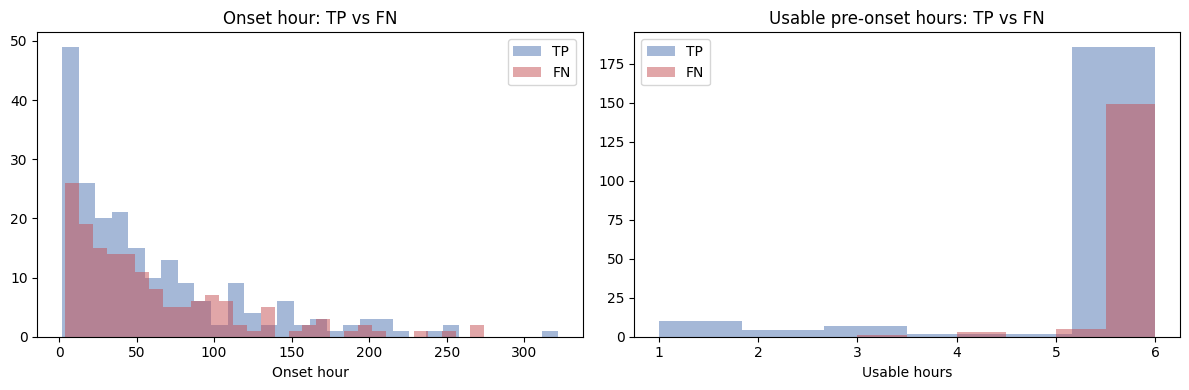

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for outcome_label, color in [("TP", "#4C72B0"), ("FN", "#C44E52")]:
    sub = fn_vs_tp[fn_vs_tp["outcome"] == outcome_label]
    axes[0].hist(sub["onset_hour"], bins=30, alpha=0.5, label=outcome_label, color=color)
    axes[1].hist(sub["usable_hours"], bins=6, alpha=0.5, label=outcome_label, color=color)
axes[0].set_title("Onset hour: TP vs FN"); axes[0].set_xlabel("Onset hour"); axes[0].legend()
axes[1].set_title("Usable pre-onset hours: TP vs FN"); axes[1].set_xlabel("Usable hours"); axes[1].legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "19_fn_vs_tp_timing.png", dpi=150)
plt.show()


## 3. False Negatives — are clinical features "too normal-looking"?

Compares key engineered features between FN and TP groups directly.


In [20]:
key_features = ["HR_mean", "Resp_mean", "MAP_mean", "Temp_mean", "WBC_mean",
                 "Lactate_count", "Lactate_missing_ratio", "ShockIndex_mean", "TempAbnormal_mean"]
key_features = [c for c in key_features if c in fn_vs_tp.columns]

feature_comparison = fn_vs_tp.groupby("outcome")[key_features].mean().T
# Columns are already correctly labeled "FN"/"TP" by groupby — no renaming needed.
display(feature_comparison)


outcome,FN,TP
HR_mean,84.462686,90.094797
Resp_mean,16.845833,19.810223
MAP_mean,83.980174,79.537825
Temp_mean,36.726673,36.595980
WBC_mean,14.778829,12.222508
Lactate_count,0.335443,0.758294
Lactate_missing_ratio,0.925527,0.839415
ShockIndex_mean,0.692948,0.771996
TempAbnormal_mean,0.177701,0.265829


## 4. False Positives — what do they have in common with true positives?

**Why this matters:** if FPs look clinically similar to TPs on paper, they
may represent genuinely at-risk patients who did not go on to develop
sepsis in this dataset's window — not necessarily "model mistakes" in the
everyday sense.


In [21]:
fp_vs_tn = patient_df_val[patient_df_val["outcome"].isin(["TN", "FP"])]
fp_feature_comparison = fp_vs_tn.groupby("outcome")[key_features].mean().T
display(fp_feature_comparison)

# Also compare FP directly against TP to see how similar they look
fp_tp_comparison = patient_df_val[patient_df_val["outcome"].isin(["FP", "TP"])].groupby("outcome")[key_features].mean().T
print("\nFP vs TP (are false alarms clinically similar to real cases?):")
display(fp_tp_comparison)


outcome,FP,TN
HR_mean,90.181526,82.943131
Resp_mean,20.062348,17.345358
MAP_mean,78.819900,84.504666
Temp_mean,36.855358,36.607647
WBC_mean,12.532453,11.658063
Lactate_count,0.514720,0.186928
Lactate_missing_ratio,0.893321,0.962525
ShockIndex_mean,0.793544,0.688715
TempAbnormal_mean,0.208080,0.159502



FP vs TP (are false alarms clinically similar to real cases?):


outcome,FP,TP
HR_mean,90.181526,90.094797
Resp_mean,20.062348,19.810223
MAP_mean,78.819900,79.537825
Temp_mean,36.855358,36.595980
WBC_mean,12.532453,12.222508
Lactate_count,0.514720,0.758294
Lactate_missing_ratio,0.893321,0.839415
ShockIndex_mean,0.793544,0.771996
TempAbnormal_mean,0.208080,0.265829


## 5. Model confidence distribution by outcome

**What?** Are FN predictions "close misses" (probability just under the
threshold) or "confidently wrong" (very low probability)? This has direct
implications for whether threshold tuning alone could help, or whether the
model is missing real signal for these patients.


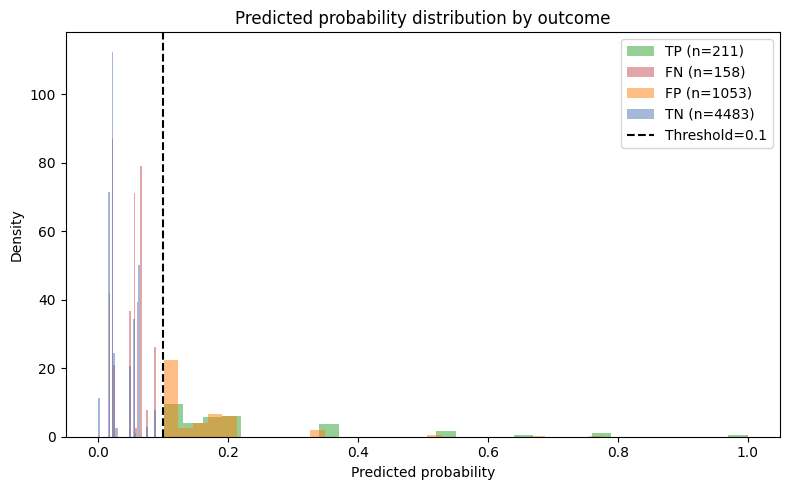

FN probability stats:
count    158.000000
mean       0.047062
std        0.021829
min        0.016364
25%        0.021497
50%        0.056017
75%        0.064516
max        0.088496
Name: pred_prob, dtype: float64


In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
for outcome_label, color in [("TP", "#2ca02c"), ("FN", "#C44E52"), ("FP", "#ff7f0e"), ("TN", "#4C72B0")]:
    sub = patient_df_val[patient_df_val["outcome"] == outcome_label]
    ax.hist(sub["pred_prob"], bins=30, alpha=0.5, label=f"{outcome_label} (n={len(sub)})", color=color, density=True)
ax.axvline(FINAL_THRESHOLD, linestyle="--", color="black", label=f"Threshold={FINAL_THRESHOLD}")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Density")
ax.set_title("Predicted probability distribution by outcome")
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "19_confidence_by_outcome.png", dpi=150)
plt.show()

print("FN probability stats:")
print(patient_df_val[patient_df_val['outcome']=='FN']['pred_prob'].describe())


## 6. Source set and demographic breakdown of errors

Checks whether errors cluster in one source_set (A vs B) or demographic
group — a preview of Phase 22's more formal subgroup analysis.


In [23]:
for col in [config.SOURCE_SET_COL, "Gender"]:
    print(f"\n--- Outcome distribution by {col} ---")
    display(pd.crosstab(patient_df_val[col], patient_df_val["outcome"], normalize="index") * 100)



--- Outcome distribution by source_set ---


outcome,FN,FP,TN,TP
source_set,,,,
A,2.552906,25.663420,66.610682,5.172993
B,2.800546,9.870219,85.382514,1.946721



--- Outcome distribution by Gender ---


outcome,FN,FP,TN,TP
Gender,,,,
0.0,3.015267,17.022901,77.061069,2.900763
1.0,2.404871,18.477930,75.007610,4.109589


## 7. Summary of findings (to be filled in based on actual output above)

This section should be completed after reviewing Sections 2-6: does the
data support the "gradual onset -> harder to catch" hypothesis? Are FPs
clinically similar to TPs (suggesting they may be near-miss/borderline
real risk cases)? Are errors concentrated in a particular source_set?


---
### What to send back to Claude after running this notebook

- Section 2's onset_hour/usable_hours comparison (TP vs FN) — does either
  group show a clear pattern (e.g. FN patients had MORE usable hours,
  meaning more gradual onset)?
- Section 3's feature comparison table
- Section 4's FP-vs-TP comparison (do false alarms look clinically similar
  to real positives?)
- Section 5's FN probability distribution (close misses vs confidently wrong)
- Section 6's source_set/gender breakdown

With that, **Phase 21 is complete**, and we move to **Phase 22 (Subgroup
Analysis)** — formally evaluating performance (ROC-AUC, PR-AUC, recall,
precision) separately by age group, gender, and ICU unit.
